# 06 Evaluation

- Computing metrics: MAPE and MdAPE
- Summarizing insights

- Output: metrics_summary.csv

## Set Up

- reloading ALL models produced up to 05_advanced models

In [1]:
# %pip install jinja2

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import os, glob
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)
from sklearn.linear_model import Ridge  

sns.set_theme(style="whitegrid")

TARGET, DATE = "ClosePrice", "CloseDate"
DATA    = sorted(glob.glob("../../data/cleaned_CRMLSSold*.csv"))[-1]
MODELS  = "../../models/week7_models.joblib"

B = joblib.load(MODELS)
registry, scaler = B["registry"], B["scaler"]
feature, structural, cat_cols, native = B["feature"], B["structural"], B["cat_cols"], B["native"]
feature_d      = B["feature_d"]
blend_weights  = B["blend_weights"]
stack_order    = B["stack_input_order"]

TREES = joblib.load("../../models/week5_6_trees.joblib")["tree_registry"] #collects from 04 and 05 notebooks
print(f"loaded {len(registry)} boosters + {len(TREES)} DT/RF = {len(registry)+len(TREES)} models")

loaded 10 boosters + 11 DT/RF = 21 models


In [2]:
# rebuilding the splits

df = pd.read_csv(DATA, parse_dates=[DATE], low_memory=False)
TEST_MONTH   = df[DATE].dt.to_period("M").astype(str).max()
TRAIN_MONTHS = min(df[DATE].dt.to_period("M").nunique() - 1, 11)

def chrono_split(data, test_month=TEST_MONTH, window=TRAIN_MONTHS, date=DATE):
    m = data[date].dt.to_period("M"); tp = pd.Period(test_month, "M")
    return data[(m >= tp - window) & (m < tp)].copy(), data[m == tp].copy()

train_df, test_df = chrono_split(df)
test_df_full = test_df.copy()                                   # untrimmed set
lo, hi = train_df[TARGET].quantile(.01), train_df[TARGET].quantile(.99)
test_df = test_df[test_df[TARGET].between(lo, hi)].copy()        # 1/99 contract
print(f"test trimmed {len(test_df):,} | full June {len(test_df_full):,}")

#helpers
def rep_onehot(fr): return fr[feature]
def rep_scaled(fr): return scaler.transform(fr[feature])
def rep_native(fr):
    X = fr[native].copy()
    for c in cat_cols: X[c] = fr[c].astype("string").fillna("Unknown").astype(str)
    return X
def rep_onehot_d(fr): return fr[feature_d]
REP = {"onehot": rep_onehot, "scaled": rep_scaled, "native": rep_native, "onehot-district": rep_onehot_d}

def mdape(yt, yp): return float(np.median(np.abs((np.asarray(yt) - yp) / np.asarray(yt))) * 100)
def metrics(yt, yp):
    yt = np.asarray(yt)
    return {"R2": r2_score(yt, yp), "MAE": mean_absolute_error(yt, yp),
            "RMSE": mean_squared_error(yt, yp) ** 0.5,
            "MAPE": mean_absolute_percentage_error(yt, yp) * 100, "MdAPE": mdape(yt, yp)}

# logging result of experiments 
RESULTS = "../../results/model_results.csv"
def log_result(model_name, version, train_r2, test_r2, change_note, target_space="raw(ClosePrice)", week=8, n_features=None):   # ← week=8 default
    n_features = len(feature) if n_features is None else n_features
    os.makedirs(os.path.dirname(RESULTS), exist_ok=True)
    row = pd.DataFrame([{
        "week": week, "model": model_name, "version": version,
        "target": target_space, "train_months": TRAIN_MONTHS,
        "test_month": TEST_MONTH, "n_features": n_features,
        "train_r2": round(train_r2, 4), "test_r2": round(test_r2, 4),
        "change_note": change_note,
    }])
    if os.path.exists(RESULTS):
        log = pd.read_csv(RESULTS)
        same = ((log["model"] == model_name) & (log["version"] == version)
                & (log["week"] == week) & (log["test_month"] == TEST_MONTH)
                & (log["train_months"] == TRAIN_MONTHS))
        log = log[~same]
        log = pd.concat([log, row], ignore_index=True)
    else:
        log = row
    log.to_csv(RESULTS, index=False)
    print(f"logged: {model_name} {version} | week {week} | n_feat {n_features} | "
            f"train R2 {train_r2:.4f} | test R2 {test_r2:.4f}")

test trimmed 12,570 | full June 12,837


In [3]:
#predictor map

predictors = {}

# 05 advanced models
for key, (est, rep) in registry.items():
    if rep == "meta":
        continue
    predictors[key] = (lambda e, r: (lambda fr: e.predict(REP[r](fr))))(est, rep)

meta_est = registry["Ensemble|stack-ridge"][0]
def stack_pred(fr):
    cols = [predictors[k](fr) for k in stack_order]
    return meta_est.predict(np.column_stack(cols))
predictors["Ensemble|stack-ridge"] = stack_pred

w_l, w_x, w_c = blend_weights
predictors["Ensemble|blend-tuned"] = (lambda fr:
    w_l * predictors[stack_order[0]](fr)
    + w_x * predictors[stack_order[1]](fr)
    + w_c * predictors[stack_order[2]](fr))

# 04 tree models
def make_tree_pred(est, feats, target):
    def predict(fr):
        p = est.predict(fr[feats])
        return np.exp(p) if target == "log" else p
    return predict
for key, (est, feats, target) in TREES.items():
    predictors[key] = make_tree_pred(est, feats, target)

print(f"total models to evaluate: {len(predictors)}")   # 11 boosters/ensembles + 11 DT/RF = 22
print(sorted(predictors.keys()))

total models to evaluate: 22
['CatBoost|A', 'CatBoost|B-tuned', 'DecisionTree|A-log', 'DecisionTree|A-raw', 'DecisionTree|B-depth', 'DecisionTree|C-leaf5', 'Ensemble|blend-tuned', 'Ensemble|stack-ridge', 'LightGBM|A', 'LightGBM|B-tuned', 'LightGBM|B-tuned+district', 'LinearRegression|baseline', 'RandomForest|A+FE', 'RandomForest|A+FE+SchoolDistrict', 'RandomForest|A+SchoolDistrict', 'RandomForest|A-log', 'RandomForest|A-raw', 'RandomForest|B-leaf5', 'RandomForest|C-tuned', 'XGBoost|A', 'XGBoost|B-tuned', 'XGBoost|B-tuned+district']


# Log-Target experiment: LGBM-log

- currently RandomForest A-log remains a leader on MAPE and MdAPE
- I haven't yet checked if a tuned gradient boost model using log instead of raw would perform better than RF A-log, and I hypothesize that it should
- If it does perform better, I will see about adding it into the Stack ensemble
    - On the condition that it doesn't negatively impact any of the metrics while improving on MdAPE
- LGBM-log is LightGBM with the same features and tuning but instead of predicting the price directly it predicts the log of the price then converts back to dollars

In [4]:
# tuned configs, pulled from the loaded models themselves
lgb_params = registry["LightGBM|B-tuned+district"][0].get_params()
xgb_params = registry["XGBoost|B-tuned+district"][0].get_params()
cat_params = registry["CatBoost|B-tuned"][0].get_params()   # includes cat_features

# same split as 05_advanced_models.ipynb
sort_idx = np.argsort(train_df[DATE].to_numpy())
val_size = int(0.10 * len(train_df))
fit_pos, val_pos = sort_idx[:-val_size], sort_idx[-val_size:]
y_all = train_df[TARGET]
y_fit, y_val = y_all.iloc[fit_pos], y_all.iloc[val_pos]
print(f"fit {len(fit_pos):,} | val {len(val_pos):,} (May)")

fit 106,423 | val 11,824 (May)


In [5]:
# LGBM tuned config, log target, +district features (full training window)
lgb_log = LGBMRegressor(**lgb_params).fit(train_df[feature_d], np.log(y_all))
predictors["LightGBM|B-tuned+district-LOG"] = lambda fr: np.exp(lgb_log.predict(fr[feature_d]))

for label, frame in [("trimmed_1_99", test_df), ("full_June", test_df_full)]:
    m = metrics(frame[TARGET].values, np.exp(lgb_log.predict(frame[feature_d])))
    print(f"{label:13} R^2 {m['R2']:.4f} | MAE ${m['MAE']:,.0f} | MAPE {m['MAPE']:.2f}% | MdAPE {m['MdAPE']:.2f}%")
print("\ntargets to beat: MdAPE 7.86 (trimmed, RF A-log) / 8.08 (full, RF A-raw)")

trimmed_1_99  R^2 0.8787 | MAE $152,848 | MAPE 11.32% | MdAPE 7.91%
full_June     R^2 0.8200 | MAE $191,651 | MAPE 12.45% | MdAPE 8.06%

targets to beat: MdAPE 7.86 (trimmed, RF A-log) / 8.08 (full, RF A-raw)


full June R^2 here is the strongest result out of all the models of untrimmed test, the 0.9+ results of the other models thus far have had a much larger gap between the 1/99 and untrimmed.

### Side-experiment - Stack4-log: all in one model

- this stack attempts to close the tail error that the 3 model ridge-stack couldn't win on (MdAPE) that is led by RandomForest (%)
- Same as ridge-stack but now includes log-target LGBM implemented above
- seeing if it could actually cover the blind spot of MdAPE

In [6]:
# fit-portion base models (honest May predictions)
lgb_f  = LGBMRegressor(**lgb_params).fit(train_df[feature_d].iloc[fit_pos], y_fit)
xgb_f  = XGBRegressor(**xgb_params).fit(train_df[feature_d].iloc[fit_pos], y_fit)
cat_f  = CatBoostRegressor(**cat_params).fit(rep_native(train_df.iloc[fit_pos]), y_fit)
log_f  = LGBMRegressor(**lgb_params).fit(train_df[feature_d].iloc[fit_pos], np.log(y_fit))

val_fr = train_df.iloc[val_pos]
val4 = np.column_stack([lgb_f.predict(val_fr[feature_d]),
                        xgb_f.predict(val_fr[feature_d]),
                        cat_f.predict(rep_native(val_fr)),
                        np.exp(log_f.predict(val_fr[feature_d]))])
meta4 = Ridge(alpha=1.0).fit(val4, y_val)
print(f"meta4 coefs (lgb, xgb, cat, lgb-LOG): {meta4.coef_.round(3)} | intercept {meta4.intercept_:,.0f}")

def stack4_pred(fr):
    return meta4.predict(np.column_stack([
        predictors["LightGBM|B-tuned+district"](fr),
        predictors["XGBoost|B-tuned+district"](fr),
        predictors["CatBoost|B-tuned"](fr),
        predictors["LightGBM|B-tuned+district-LOG"](fr)]))
predictors["Ensemble|stack4-log"] = stack4_pred

for label, frame in [("trimmed_1_99", test_df), ("full_June", test_df_full)]:
    m = metrics(frame[TARGET].values, stack4_pred(frame))
    print(f"stack4 {label:13} R2 {m['R2']:.4f} | MAE ${m['MAE']:,.0f} | MAPE {m['MAPE']:.2f}% | MdAPE {m['MdAPE']:.2f}%")
print("\n3-member stack baseline: trimmed 0.9064 | MdAPE ~8.0 | full 0.6239 / MdAPE 8.14")

meta4 coefs (lgb, xgb, cat, lgb-LOG): [ 0.076 -0.097  0.247  0.786] | intercept 28,959
stack4 trimmed_1_99  R2 0.8905 | MAE $151,125 | MAPE 11.92% | MdAPE 8.18%
stack4 full_June     R2 0.8020 | MAE $191,993 | MAPE 13.38% | MdAPE 8.35%

3-member stack baseline: trimmed 0.9064 | MdAPE ~8.0 | full 0.6239 / MdAPE 8.14


### Interpret:

- Ensemble stack ridge:
    - *winner of the typical priced properties* (mid-market), best MAE
    - underpredicts luxury tail still
- LGBM-log:
    - Full June R^2 here is the *strongest result out of all the models of untrimmed test*, the 0.9+ results of the other models thus far have had a much larger gap between the 1/99 and untrimmed
        - when the test set is trimmed, it excludes the outliers of property costs, this experiment improves the prediction errors that show up with the luxury tail

- Stack4-log: 
    - all in one model (stack4) fails because of the clashed evaluation weights
    - full market needs log, trimmed stack wants raw, single model can't cover all bases after all (blending failure, though potentilal to iterate and retry but unlikely to be as strong as LGBM-log was)
    - just dillutes accuracy overall

- Important finding: luxury tail is fixed by using ClosePrice in log, not raw. Raw target ClosePrice remains top accuracy for the mid-market of typical CA properties, but to blend them into one model loses accuracy on other bands.

In [7]:
y_tr = train_df[TARGET].values

lgb_log_train_r2 = r2_score(y_tr, np.exp(lgb_log.predict(train_df[feature_d])))
lgb_log_test_r2  = r2_score(test_df[TARGET].values, np.exp(lgb_log.predict(test_df[feature_d])))

log_result("LightGBM", "B-tuned+district-LOG", lgb_log_train_r2, lgb_log_test_r2,
           "LOG target on tuned feature_d config + fixes untrimmed luxury-tail collapse",
           target_space="log(ClosePrice)", n_features=len(feature_d))

stack4_train_r2 = r2_score(y_tr, stack4_pred(train_df))
stack4_test_r2  = r2_score(test_df[TARGET].values, stack4_pred(test_df))

log_result("Ensemble", "stack4-log", stack4_train_r2, stack4_test_r2,
           f"all in one model but fails due to overweighting",
           target_space="raw(ClosePrice)", n_features=len(feature_d))

logged: LightGBM B-tuned+district-LOG | week 8 | n_feat 1547 | train R2 0.9180 | test R2 0.8787
logged: Ensemble stack4-log | week 8 | n_feat 1547 | train R2 0.8929 | test R2 0.8905


# Overall Metrics 

- On all models created thus far (Linear, Random Forest, Decision Tree, Light GBM, XGBoost, CatBoost)

In [8]:
def evaluate(frame, label):
    yt = frame[TARGET].values
    rows, preds = [], {}
    for key, pfn in predictors.items():
        yp = pfn(frame); preds[key] = yp
        rows.append({"model": key, "eval_set": label, **metrics(yt, yp)})
    return pd.DataFrame(rows), preds

full_tbl, preds_full = evaluate(test_df_full, "full_June")
trim_tbl, preds_trim = evaluate(test_df,      "trimmed_1_99")
summary = (pd.concat([full_tbl, trim_tbl], ignore_index=True)
           .sort_values(["eval_set", "MdAPE"]).reset_index(drop=True))

summary.round(4).to_csv("../../results/metrics_summary.csv", index=False)

for label in ["full_June", "trimmed_1_99"]:
    sub = summary[summary["eval_set"] == label].drop(columns="eval_set")
    display(sub.style
            .format({"R2": "{:.3f}", "MAE": "${:,.0f}", "RMSE": "${:,.0f}",
                     "MAPE": "{:.2f}%", "MdAPE": "{:.2f}%"})
            .hide(axis="index").set_caption(label))
    
print("\nwrote ../../results/metrics_summary.csv")

model,R2,MAE,RMSE,MAPE,MdAPE
LightGBM|B-tuned+district-LOG,0.820,"$191,651","$651,556",12.45%,8.06%
RandomForest|A-raw,0.552,"$231,221","$1,027,971",14.58%,8.08%
RandomForest|A+SchoolDistrict,0.553,"$229,912","$1,027,443",14.47%,8.10%
RandomForest|A-log,0.543,"$230,597","$1,038,152",13.75%,8.12%
Ensemble|stack-ridge,0.624,"$209,133","$941,937",13.51%,8.14%
RandomForest|A+FE+SchoolDistrict,0.550,"$232,975","$1,030,099",14.58%,8.18%
Ensemble|blend-tuned,0.613,"$211,392","$955,679",13.31%,8.22%
RandomForest|A+FE,0.549,"$234,879","$1,031,956",14.76%,8.27%
RandomForest|B-leaf5,0.543,"$237,572","$1,038,660",14.93%,8.35%
Ensemble|stack4-log,0.802,"$191,993","$683,371",13.38%,8.35%


model,R2,MAE,RMSE,MAPE,MdAPE
RandomForest|A-log,0.877,"$157,728","$309,173",11.56%,7.86%
RandomForest|A-raw,0.879,"$159,770","$306,422",12.15%,7.87%
RandomForest|A+SchoolDistrict,0.881,"$158,375","$303,464",12.08%,7.88%
LightGBM|B-tuned+district-LOG,0.879,"$152,848","$306,829",11.32%,7.91%
Ensemble|stack-ridge,0.906,"$146,915","$269,628",11.72%,7.93%
RandomForest|A+FE+SchoolDistrict,0.877,"$161,196","$309,500",12.28%,7.96%
Ensemble|blend-tuned,0.904,"$147,136","$272,502",11.47%,8.01%
RandomForest|A+FE,0.874,"$162,914","$312,214",12.41%,8.03%
RandomForest|B-leaf5,0.870,"$164,909","$317,816",12.48%,8.12%
Ensemble|stack4-log,0.890,"$151,125","$291,580",11.92%,8.18%



wrote ../../results/metrics_summary.csv


### Interpret

- Comparing across all the models, the best is:

- Of the 1/99 trimmed sets:
    R^2: Ensemble stack-ridge (0.9064)
    MAE: Ensemble stack-ridge ($146,915)
    RMSE: Ensemble stack-ridge ($269,628)
    MAPE: LGBM-log 11.32% (2nd: blend 11.47%)
    MdAPE: RandomForest|A-log (7.86%)

- of the UNtrimmed test set
    R^2: LGBM-log 0.8200 (2nd: stack4 0.8020; best raw 0.6239)
    MAE: LGBM-log ($191,651)
    RMSE: LGBM-log ($651,556 (vs stack $941,937))
    MAPE: LGBM-log (12.45%)
    MdAPE: LGBM-log (8.06%)

- Major Takeaway: the best model isn't going to clear all metrics, it depends
    - Looking at the dollar metrics (R^2, RMSE, MAE), raw-target ensemble wins
    - The % metrics (MAPE, MdAPE), log-target LGBM model 
    - full-June R^2 leads the best raw ensemble by +0.20

In [9]:
# winners per metric per eval set
for label in ["trimmed_1_99", "full_June"]:
    sub = summary[summary["eval_set"] == label]
    print(f"\n== {label} ==")
    for m, asc in [("R2", False), ("MAE", True), ("RMSE", True), ("MAPE", True), ("MdAPE", True)]:
        best = sub.sort_values(m, ascending=asc).iloc[0]
        runner = sub.sort_values(m, ascending=asc).iloc[1]
        print(f"{m:6}: {best['model']:34} {best[m]:>12,.4f}   (2nd: {runner['model']}, {runner[m]:,.4f})")


== trimmed_1_99 ==
R2    : Ensemble|stack-ridge                     0.9064   (2nd: Ensemble|blend-tuned, 0.9043)
MAE   : Ensemble|stack-ridge               146,914.7102   (2nd: Ensemble|blend-tuned, 147,136.3157)
RMSE  : Ensemble|stack-ridge               269,627.8922   (2nd: Ensemble|blend-tuned, 272,502.3432)
MAPE  : LightGBM|B-tuned+district-LOG           11.3162   (2nd: Ensemble|blend-tuned, 11.4748)
MdAPE : RandomForest|A-log                       7.8594   (2nd: RandomForest|A-raw, 7.8709)

== full_June ==
R2    : LightGBM|B-tuned+district-LOG            0.8200   (2nd: Ensemble|stack4-log, 0.8020)
MAE   : LightGBM|B-tuned+district-LOG      191,650.5834   (2nd: Ensemble|stack4-log, 191,992.5287)
RMSE  : LightGBM|B-tuned+district-LOG      651,555.9812   (2nd: Ensemble|stack4-log, 683,370.6422)
MAPE  : LightGBM|B-tuned+district-LOG           12.4537   (2nd: Ensemble|blend-tuned, 13.3076)
MdAPE : LightGBM|B-tuned+district-LOG            8.0581   (2nd: RandomForest|A-raw, 8.0788)


In [10]:
# checking the worst 20 rows for the stack vs the log model (reverifying the winners shown above)

yp_stack = preds_full["Ensemble|stack-ridge"]
yp_log   = preds_full["LightGBM|B-tuned+district-LOG"]
y_true   = test_df_full[TARGET].values

worst = np.argsort(np.abs(y_true - yp_stack))[-20:][::-1]
chk = pd.DataFrame({"actual":     y_true[worst].round(0),
                    "stack_pred": yp_stack[worst].round(0),
                    "log_pred":   yp_log[worst].round(0)})
chk["stack_err"] = (chk["actual"] - chk["stack_pred"]).abs()
chk["log_err"]   = (chk["actual"] - chk["log_pred"]).abs()
print(chk.to_string(index=False))
print(f"\nlog model better on {int((chk['log_err'] < chk['stack_err']).sum())}/20 of the stack's worst rows")

    actual  stack_pred   log_pred  stack_err    log_err
46950000.0   6464237.0 25069657.0 40485763.0 21880343.0
38000000.0   7363446.0 26021014.0 30636554.0 11978986.0
33333333.0   5640219.0 12872906.0 27693114.0 20460427.0
31250000.0   5786588.0 16080737.0 25463412.0 15169263.0
29995000.0   5512147.0 13652614.0 24482853.0 16342386.0
28500000.0   5242327.0  9165623.0 23257673.0 19334377.0
27500000.0   6233728.0 12654246.0 21266272.0 14845754.0
25500000.0   6342098.0 18356117.0 19157902.0  7143883.0
24500000.0   5786537.0 11965087.0 18713463.0 12534913.0
24500000.0   6715894.0 14818428.0 17784106.0  9681572.0
23000000.0   6649896.0 10365288.0 16350104.0 12634712.0
22500000.0   6439984.0 23483120.0 16060016.0   983120.0
22500000.0   6771959.0 18700378.0 15728041.0  3799622.0
19950000.0   5704409.0 11153412.0 14245591.0  8796588.0
19000000.0   5610383.0  8027561.0 13389617.0 10972439.0
19000000.0   5795087.0  6390853.0 13204913.0 12609147.0
17500000.0   6657255.0 12932181.0 10842745.0  45

### Interpret:

- the results show that stack has the worser accuracy for high value properties from 14 Million to 47 million (predicts $5-7 million), extreme underprediciton and due to the 1/99 trimmed training that I established for all the models

## Control experiment: raw target

- same UNTRIMMED training data as lgb_log
- isolates the log-target effect from the train-trim effect

In [11]:
lgb_raw_ut = LGBMRegressor(**lgb_params).fit(train_df[feature_d], y_all)
for label, frame in [("trimmed_1_99", test_df), ("full_June", test_df_full)]:
    m = metrics(frame[TARGET].values, lgb_raw_ut.predict(frame[feature_d]))
    print(f"raw-untrimmed {label:13} R2 {m['R2']:.4f} | MAE ${m['MAE']:,.0f} | "
          f"MAPE {m['MAPE']:.2f}% | MdAPE {m['MdAPE']:.2f}%")
print("\ncompare: LGBM-log 0.8787/0.8200 | LGBM+district (trimmed-train, raw) 0.8989/0.5957")
log_result("LightGBM", "B-tuned +district -control",
           r2_score(y_tr, lgb_raw_ut.predict(train_df[feature_d])),
           r2_score(test_df[TARGET].values, lgb_raw_ut.predict(test_df[feature_d])),
           "CONTROL: raw target on untrimmed train; isolates train-trim effect from log-target effect",
           target_space="raw(ClosePrice)", n_features=len(feature_d))

raw-untrimmed trimmed_1_99  R2 0.8464 | MAE $169,543 | MAPE 13.02% | MdAPE 9.03%
raw-untrimmed full_June     R2 0.8115 | MAE $208,721 | MAPE 14.35% | MdAPE 9.24%

compare: LGBM-log 0.8787/0.8200 | LGBM+district (trimmed-train, raw) 0.8989/0.5957
logged: LightGBM B-tuned +district -control | week 8 | n_feat 1547 | train R2 0.9594 | test R2 0.8464


In [12]:
#log target on TRIMMED training data
train_trim = train_df[train_df[TARGET].between(lo, hi)]
lgb_log_tt = LGBMRegressor(**lgb_params).fit(train_trim[feature_d], np.log(train_trim[TARGET]))
for label, frame in [("trimmed_1_99", test_df), ("full_June", test_df_full)]:
    m = metrics(frame[TARGET].values, np.exp(lgb_log_tt.predict(frame[feature_d])))
    print(f"log-trimmedtrain {label:13} R2 {m['R2']:.4f} | MAE ${m['MAE']:,.0f} | MdAPE {m['MdAPE']:.2f}%")

log_result("LightGBM", "B-tuned+district-LOG-trimtrain",
           r2_score(train_trim[TARGET].values, np.exp(lgb_log_tt.predict(train_trim[feature_d]))),
           r2_score(test_df[TARGET].values,   np.exp(lgb_log_tt.predict(test_df[feature_d]))),
           "best simple single for trimmed contract",
           target_space="log(ClosePrice)", n_features=len(feature_d))

log-trimmedtrain trimmed_1_99  R2 0.8977 | MAE $148,255 | MdAPE 7.91%
log-trimmedtrain full_June     R2 0.6332 | MAE $209,298 | MdAPE 8.10%
logged: LightGBM B-tuned+district-LOG-trimtrain | week 8 | n_feat 1547 | train R2 0.9392 | test R2 0.8977


### Interpret

- log + trimmed train is technically the best simple model on trimmed set
- control experiment shows untrimmed result of 0.8115 from raw target which is a large jump that came from untrimmed training set and also qualities inclusion of a log target after looking at the worst 20 rows
- raw target does need the trim but the log target doesn't

# Price Bands breakdown

Determining the better price band using the untrimmed data
- MdAPE ideally should be lower than higher
- Quintiles


rows per band: {'Q1 ($12k–$575k)': 2609, 'Q2 ($575k–$800k)': 2544, 'Q3 ($800k–$1.1M)': 2559, 'Q4 ($1.1M–$1.7M)': 2559, 'Q5 ($1.7M–$47M)': 2566}


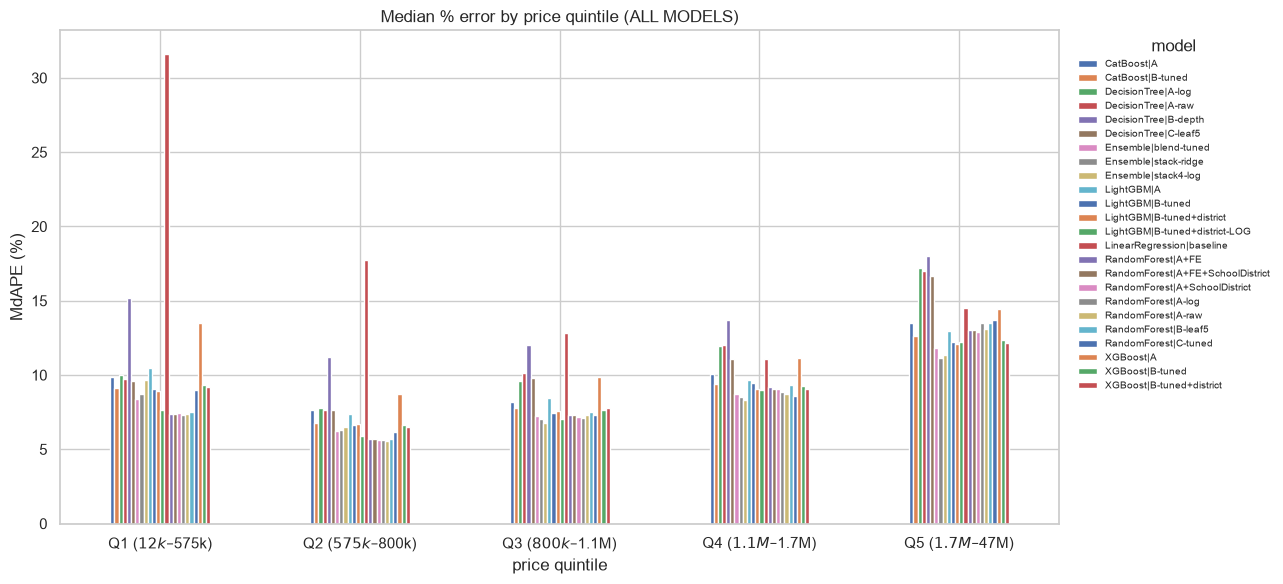

In [13]:
# bands  = [(0, 5e5), (5e5, 1e6), (1e6, 2e6), (2e6, 5e6), (5e6, np.inf)]
# labels = ["<$500k", "$500k–1M", "$1M–2M", "$2M–5M", "$5M+"]
yt = test_df_full[TARGET].values

q_edges  = np.quantile(yt, [0, .2, .4, .6, .8, 1.0])
def fmt(v): return f"${v/1e6:.2g}M" if v >= 1e6 else f"${v/1e3:.0f}k"
labels = [f"Q{i+1} ({fmt(q_edges[i])}–{fmt(q_edges[i+1])})" for i in range(5)]
qbin   = pd.qcut(yt, 5, labels=False)   

band_rows = []
for key in preds_full:
    yp = preds_full[key]
    for i, lab in enumerate(labels):
        msk = qbin == i
        band_rows.append({"model": key, "band": lab, "n": int(msk.sum()),
                          "MdAPE": round(mdape(yt[msk], yp[msk]), 2),
                          "MAPE":  round(mean_absolute_percentage_error(yt[msk], yp[msk]) * 100, 2)})
band_df = pd.DataFrame(band_rows)
mdape_pivot = band_df.pivot(index="band", columns="model", values="MdAPE").reindex(labels)
print("\nrows per band:", band_df.groupby("band")["n"].first().reindex(labels).to_dict())

STRONG = ["Ensemble|stack-ridge", "Ensemble|blend-tuned", "LightGBM|B-tuned+district-LOG", "XGBoost|B-tuned+district", "LightGBM|B-tuned", "CatBoost|B-tuned", "RandomForest|A-raw", "RandomForest|A-log", "RandomForest|A+SchoolDistrict"]
strong = [m for m in STRONG if m in mdape_pivot.columns]   # keep only ones present

fig, ax = plt.subplots(figsize=(13, 6))
mdape_pivot.plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("MdAPE (%)"); ax.set_xlabel("price quintile")
ax.set_title("Median % error by price quintile (ALL MODELS)")
ax.legend(title="model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

top 5 (one per family): ['LightGBM|B-tuned+district-LOG', 'RandomForest|A-raw', 'Ensemble|stack-ridge', 'XGBoost|B-tuned+district', 'CatBoost|B-tuned']


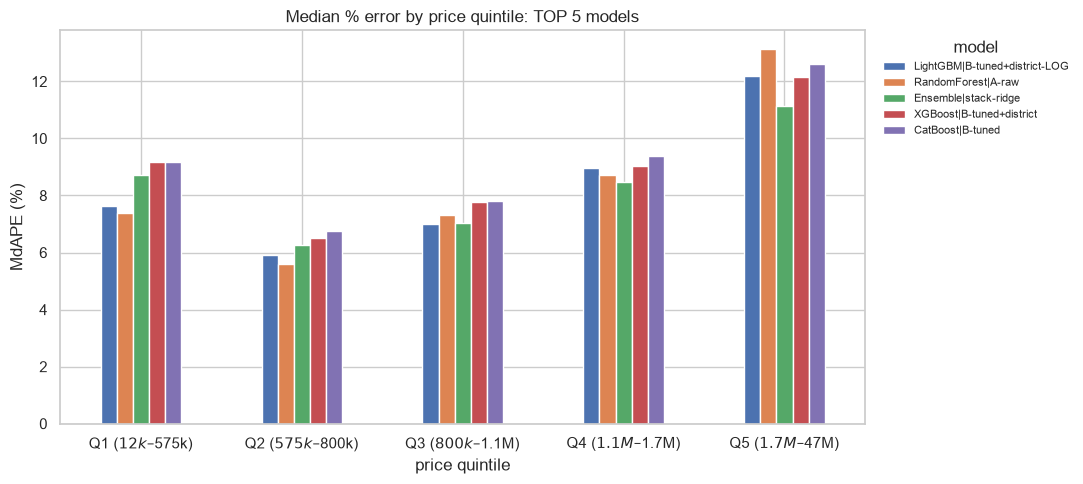

In [14]:
# Top-5 quintile view with the best model per family (keeps only the strongest RF, LGBM, XGB, CatBoost, Ensemble)

fj = summary[summary["eval_set"] == "full_June"].copy()
fj["family"] = fj["model"].str.split("|").str[0]
top5 = (fj.sort_values("MdAPE").groupby("family").head(1)
          .sort_values("MdAPE").head(5)["model"].tolist())
print("top 5 (one per family):", top5)

fig, ax = plt.subplots(figsize=(11, 5))
mdape_pivot[top5].plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("MdAPE (%)"); ax.set_xlabel("price quintile")
ax.set_title("Median % error by price quintile: TOP 5 models")
ax.legend(title="model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

### Interpret

Top-5 (one per family, data-selected by full-June MdAPE): LGBM-log, RF A-raw, stack-ridge, XGB+district, CatBoost.
- RF leads the bottom two quintiles
- LGBM-log and the stack tie in Q3
- stack leads Q4–Q5 on the median

Note:
- LGBM-log's full-June sweep (R², MAE, RMSE) doesn't show here because these bars are medians
- typical Q5 home is predicted fine by raw models

In [15]:
joblib.dump({
    "LightGBM|B-tuned+district-LOG": (lgb_log, "onehot-district-log"),
    "Ensemble|stack4-log":           (meta4,   "meta4"),
    "stack4_input_order": stack_order + ["LightGBM|B-tuned+district-LOG"],
    "feature_d": feature_d,
    "note": "log-target models from 06 evaluation experiment; lgb_log predicts log(ClosePrice)",
}, "../../models/week8_log_models.joblib")
print("saved week8_log_models.joblib")

saved week8_log_models.joblib


In [17]:
# exporting comprehensive model.pkl with lgb log

model    = lgb_log
features = list(feature_d)

zip_cols      = [c for c in features if c.startswith("Zip_")]
city_cols     = [c for c in features if c.startswith("City_")]
district_cols = [c for c in features if c.startswith("District_")]
onehot = set(zip_cols + city_cols + district_cols)
structural_cols = [c for c in features if c not in onehot]   # numerics/booleans the user provides

def build_lut(frame, raw_col, onehot_cols):
    present = [c for c in onehot_cols if c in frame.columns]
    lut = {}
    if raw_col in frame.columns and present:
        sub = frame[[raw_col] + present].dropna(subset=[raw_col])
        for val, g in sub.groupby(raw_col):
            row = g[present].iloc[0].astype(float)
            hot = row.index[row.to_numpy() == 1]
            if len(hot):
                lut[str(val)] = hot[0]
    return lut

zip_lut      = build_lut(df, "PostalCode",     zip_cols)
city_lut     = build_lut(df, "City",           city_cols)
district_lut = build_lut(df, "SchoolDistrict", district_cols)

def majority_map(frame, key, val):
    if key in frame.columns and val in frame.columns:
        s = (frame.dropna(subset=[key, val])
                  .groupby(key)[val].agg(lambda x: x.value_counts().index[0]))
        return {str(k): str(v) for k, v in s.items()}
    return {}

zip_to_district  = majority_map(df, "PostalCode", "SchoolDistrict")
city_to_district = majority_map(df, "City",        "SchoolDistrict")

transform_samples = {}
for logc, rawc in [("LivingArea_log", "LivingArea"),
                   ("LotSizeAcres_log", "LotSizeAcres")]:
    if logc in df.columns and rawc in df.columns:
        transform_samples[logc] = (
            df[[rawc, logc]].dropna().head(8).round(6).to_dict("list"))

bundle = {
    "model": model,
    "target": "log(ClosePrice)  -->  price = np.exp(prediction)",
    "features": features,                
    "structural_cols": structural_cols, 
    "zip_cols": zip_cols, "city_cols": city_cols, "district_cols": district_cols,
    "zip_lut": zip_lut,                  
    "city_lut": city_lut,               
    "district_lut": district_lut,        
    "zip_to_district": zip_to_district,  # PostalCode --> SchoolDistrict
    "city_to_district": city_to_district, # City --> SchoolDistrict
    "transform_samples": transform_samples,
}

os.makedirs("../../models", exist_ok=True)
OUT = "../../models/model.pkl"
joblib.dump(bundle, OUT)

print("LGBM log model bundle saved to ../../models/model.pkl")

LGBM log model bundle saved to ../../models/model.pkl


# Final Decisions

- Trimmed 1/99 (mid-market): 
    - Ensemble stack-ridge
        - R^2 0.9064, MAE $146.9k, RMSE $269.6k
    - Single model alternative: log + trimmed-train LGBM (0.8977, MdAPE 7.91) 

- Full market WITH luxury (high end): 
    - LGBM-log (untrimmed-train)
        - sweeps all five metrics (R^2 0.8200, MAE $191.7k, RMSE $651.6k, MAPE 12.45%, MdAPE 8.06%)
        - Verified on the stack's 20 worst rows (better on 20/20)

- Control experiment:
    - Root cause of the untrimmed set collapse: the 1/99 training trim capped every raw model at ~$6.3M
        - coverage comes from untrimmed training
        - accuracy comes from the log target
        - the log target is also robust to the trim choice
- All in one model experiment: stack4 (merging contracts into one meta-learner)
    - tested but rejected 
        - May-fit Ridge over-weights the log member

- Final thoughts: LGBM-log on untrimmed training offers the best full-market model and simplest to deploy!

### Meeting Notes:

- Anvith: 
    - XGBoost wins
- Shashank:
    - XGBoost
    - METRICS:
        - price band quintiles
        - 20-40 , 40-60
        - error by geography
            - by city
- Mario: 
    - CatBoost comparison
    - trained 5 models
    - XGBoost wins
    - plot every model
    - price bands
        - compare XGBoost and CatBoost
        - XGBoost still wins across all the bands (lowest error) - 0.85 
- Soyeon:
    - error analysis
    - XGBoost log and raw target
    - a lot of error review 
    - Graph by quintile
    - living area bin
    - missing feature count
    - price was still the main drive
        - luxury homes were underpredicted
        - added log transformmed size features
        - tried sample weighting 
            - made lower price compiling worse
        - added local geographic price features
            - improved 
        - blended raw and log1p blending
            - log1p was better but performed worse on high price homes
            - trained by blending
            - Q5 error increased
    - final: local price features + blending 
        - improved Q5 significantly but still a challenge

Next Steps:
- re-doing XGBoost and proper time splitting (05_advanced_models.ipynb)
- experimenting beyond just XGBoost improvement